In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(rc={'axes.facecolor': "#FDF3FB"})
sns.set_palette("cool")  


In [ ]:
df = pd.read_csv('../datos/records_anuales.csv')

df['fecha_inicio'] = pd.to_datetime(df['fecha_inicio'])
df['fecha_fin'] = pd.to_datetime(df['fecha_fin'])

# identificar registros anuales vs mensuales
df['dias'] = (df['fecha_fin'] - df['fecha_inicio']).dt.days

# los anuales tienen ~365 días, mensuales tienen ~28-31 días
df_anual = df[df['dias'] > 100].copy()  
df_mensual = df[df['dias'] <= 100].copy()  


df_anual['year'] = df_anual['fecha_inicio'].dt.year
df_mensual['year'] = df_mensual['fecha_inicio'].dt.year

In [32]:
comparacion = []
for year in range(2012, 2026):
    total_anual = df_anual[df_anual['year'] == year]['total'].values[0]
    suma_meses = df_mensual[df_mensual['year'] == year]['total'].sum()
    diferencia = total_anual - suma_meses
    porcentaje_diff = (diferencia / total_anual * 100) if total_anual > 0 else 0
    
    comparacion.append({
        'year': year,
        'total_anual': total_anual,
        'suma_meses': suma_meses,
        'diferencia': diferencia,
        'porcentaje_diff': porcentaje_diff
    })

df_comp = pd.DataFrame(comparacion)

print("Comparación anual vs suma de meses")
print(df_comp)


Comparación anual vs suma de meses
    year  total_anual  suma_meses  diferencia  porcentaje_diff
0   2012         4882        5572        -690       -14.133552
1   2013         5315        6025        -710       -13.358420
2   2014         6179        7013        -834       -13.497330
3   2015         5288        5941        -653       -12.348714
4   2016         6314        6955        -641       -10.152043
5   2017         7835        8617        -782        -9.980855
6   2018         8325        8441        -116        -1.393393
7   2019        25359       29346       -3987       -15.722229
8   2020        19789       22978       -3189       -16.115013
9   2021        13392       16070       -2678       -19.997013
10  2022        13096       16423       -3327       -25.404704
11  2023        14757       18164       -3407       -23.087348
12  2024        17088       21459       -4371       -25.579354
13  2025        20536       25152       -4616       -22.477600


In [33]:
df_comp_melted = df_comp.melt(id_vars=['year'], 
                               value_vars=['total_anual', 'suma_meses'],
                               var_name='Tipo', 
                               value_name='Total')
df_comp_melted['Tipo'] = df_comp_melted['Tipo'].map({
    'total_anual': 'Total anual',
    'suma_meses': 'Suma meses'
})

In [43]:
df_comp_melted.head()

,year,Tipo,Total
0,2012,Total anual,4882
1,2013,Total anual,5315
2,2014,Total anual,6179
3,2015,Total anual,5288
4,2016,Total anual,6314


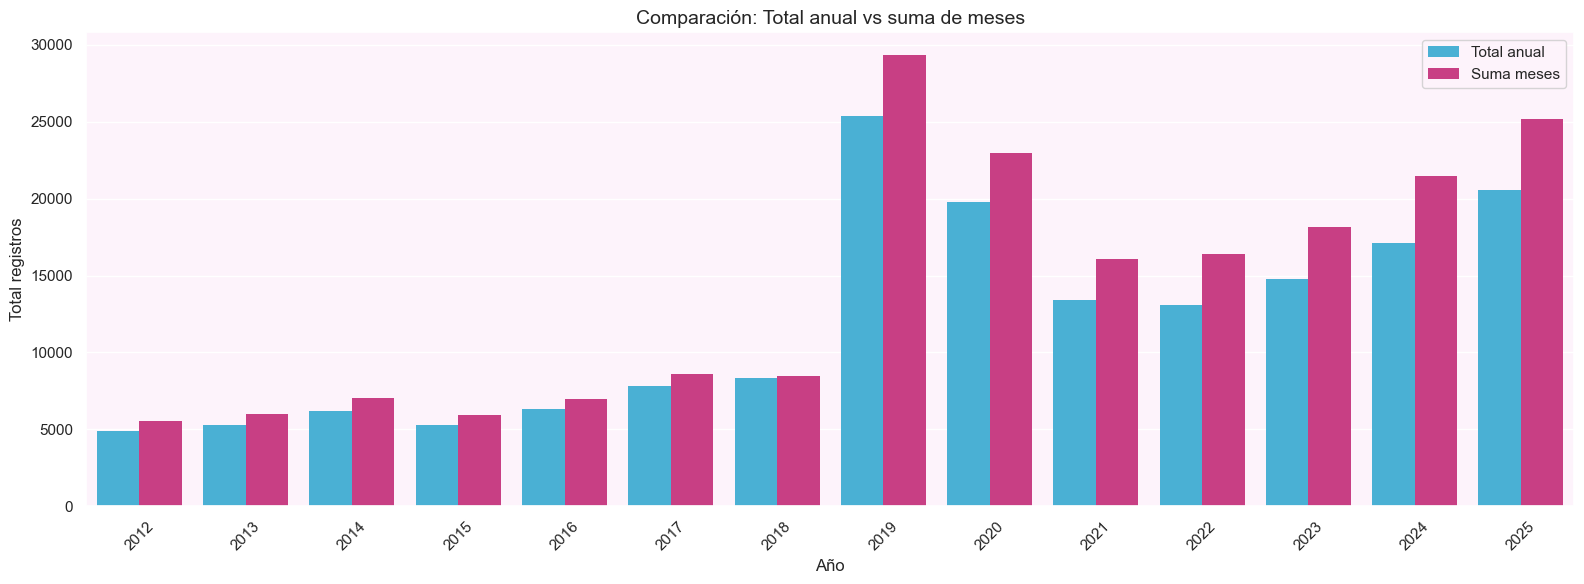

In [34]:
plt.figure(figsize=(16, 6))
sns.barplot(data=df_comp_melted, x='year', y='Total', hue='Tipo', 
            palette={'Total anual': "#33bbeb", 'Suma meses': '#df2884'}, 
            linewidth=0)
plt.ylabel('Total registros', fontsize=12)
plt.xlabel('Año', fontsize=12)
plt.title('Comparación: Total anual vs suma de meses', fontsize=14)#, fontweight='bold')
plt.legend(title='')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('comparacion_anual_vs_mensual.png', dpi=300, bbox_inches='tight')
plt.show()


In [39]:
df_comp.head()

,year,total_anual,suma_meses,diferencia,porcentaje_diff
0,2012,4882,5572,-690,-14.133552
1,2013,5315,6025,-710,-13.358420
2,2014,6179,7013,-834,-13.497330
3,2015,5288,5941,-653,-12.348714
4,2016,6314,6955,-641,-10.152043


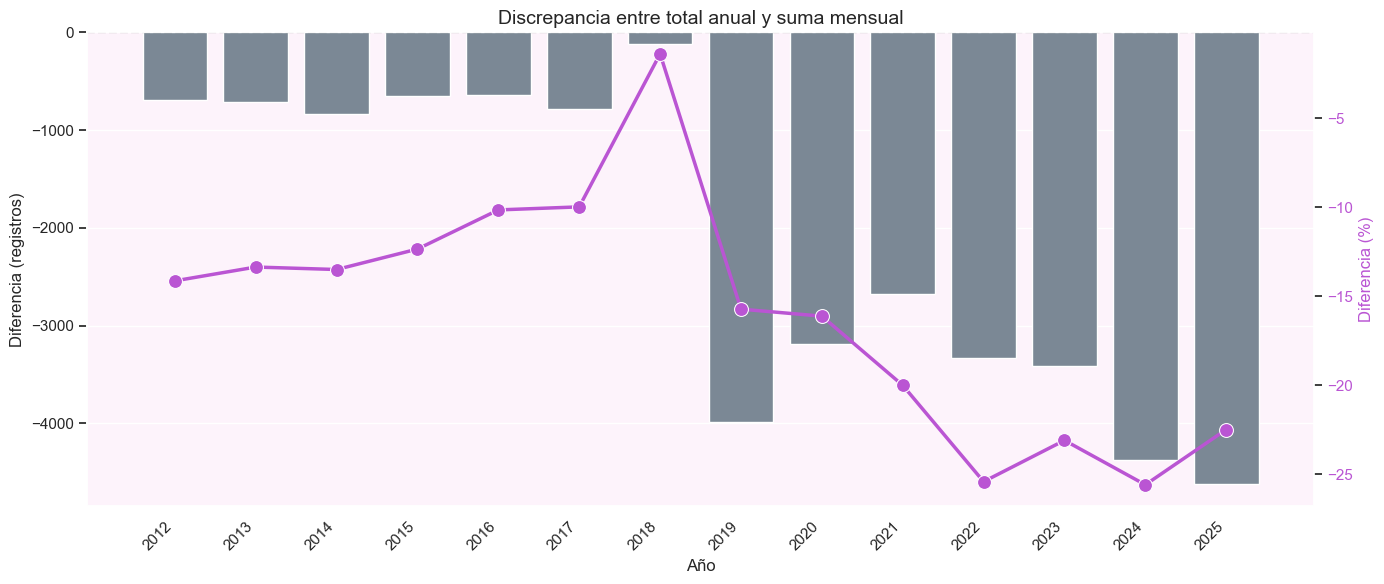

In [49]:
df_plot = df_comp.copy()
df_plot['year'] = df_plot['year'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(data=df_plot, x='year', y='diferencia', color='lightslategray', 
        ax=ax)
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Diferencia (registros)', fontsize=12)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax2 = ax.twinx()
sns.lineplot(data=df_plot, x='year', y='porcentaje_diff',
    marker='o', linewidth=2.5, markersize=10, color='mediumorchid',
    ax=ax2
)
ax2.set_ylabel('Diferencia (%)', fontsize=12, color='mediumorchid')
ax2.tick_params(axis='y', labelcolor='mediumorchid')
ax2.grid(False)
plt.title('Discrepancia entre total anual y suma mensual', fontsize=14)
plt.tight_layout()
plt.savefig('discrepancia_porcentual.png', dpi=300, bbox_inches='tight')
plt.show()


In [36]:
pivot_mensual = df_mensual.pivot_table(
    values='total',
    index=df_mensual['fecha_inicio'].dt.month,
    columns=df_mensual['fecha_inicio'].dt.year,
    aggfunc='sum'
)

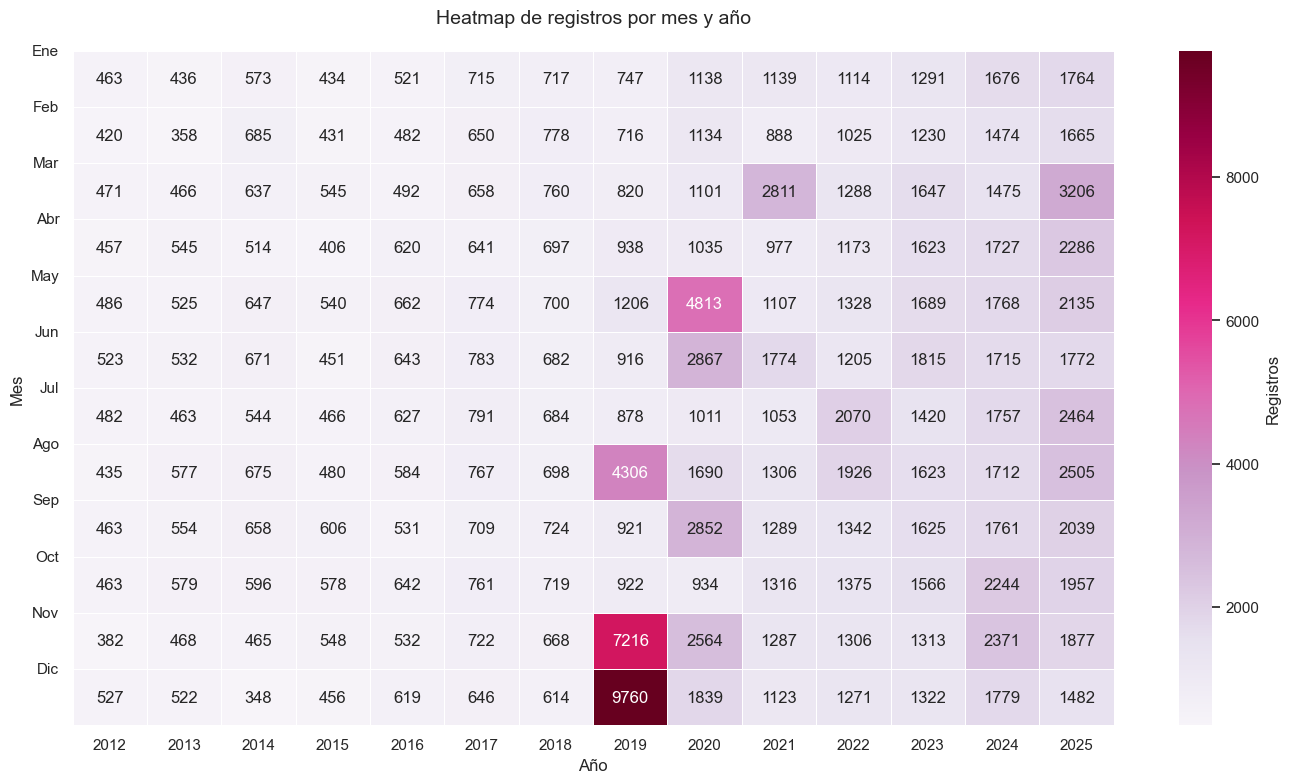

In [37]:
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_mensual, annot=True, fmt='.0f', cmap='PuRd', 
            linewidths=0.5, cbar_kws={'label': 'Registros'})
plt.title('Heatmap de registros por mes y año', fontsize=14, pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Mes', fontsize=12)
plt.yticks(range(12), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                        'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'], rotation=0)
plt.tight_layout()
plt.savefig('heatmap_mensual.png', dpi=300, bbox_inches='tight')
plt.show()



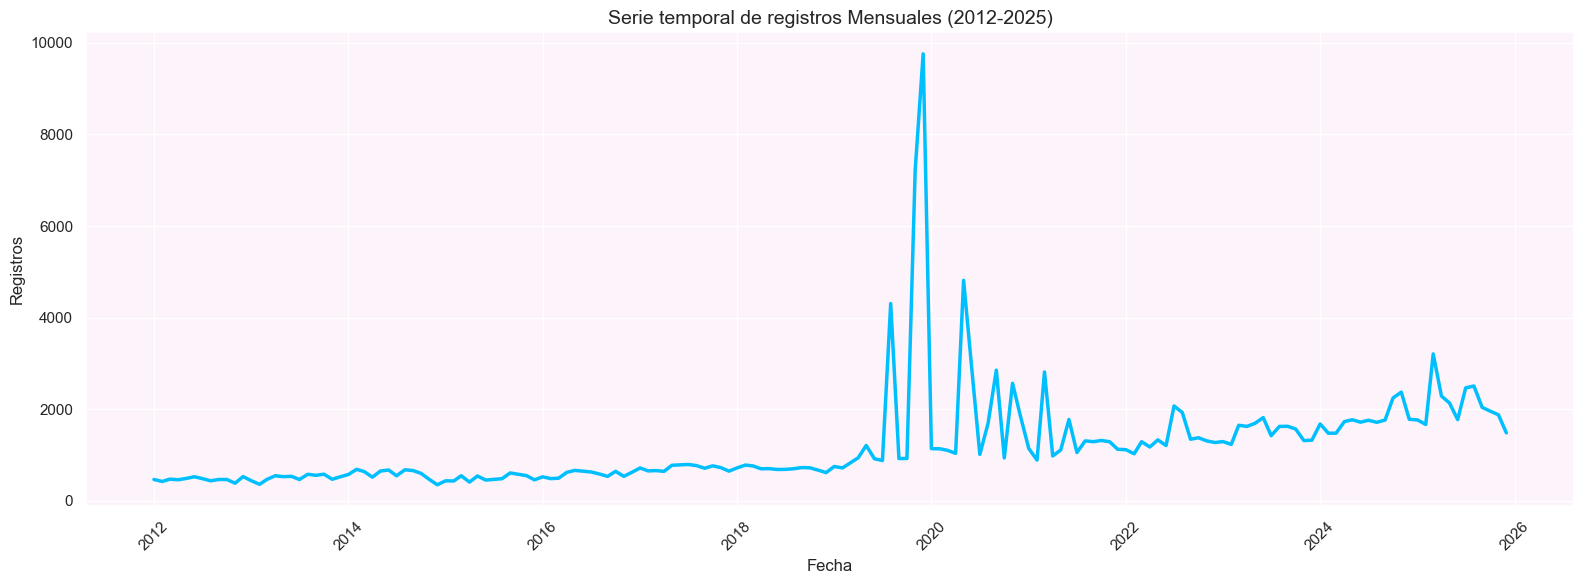

In [45]:
plt.figure(figsize=(16, 6))
df_mensual_sorted = df_mensual.sort_values('fecha_inicio')
sns.lineplot(data=df_mensual_sorted, x='fecha_inicio', y='total', 
            linewidth=2.5, color='deepskyblue')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Registros', fontsize=12)
plt.title('Serie temporal de registros Mensuales (2012-2025)', fontsize=14)#, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('serie_temporal.png', dpi=300, bbox_inches='tight')
plt.show()


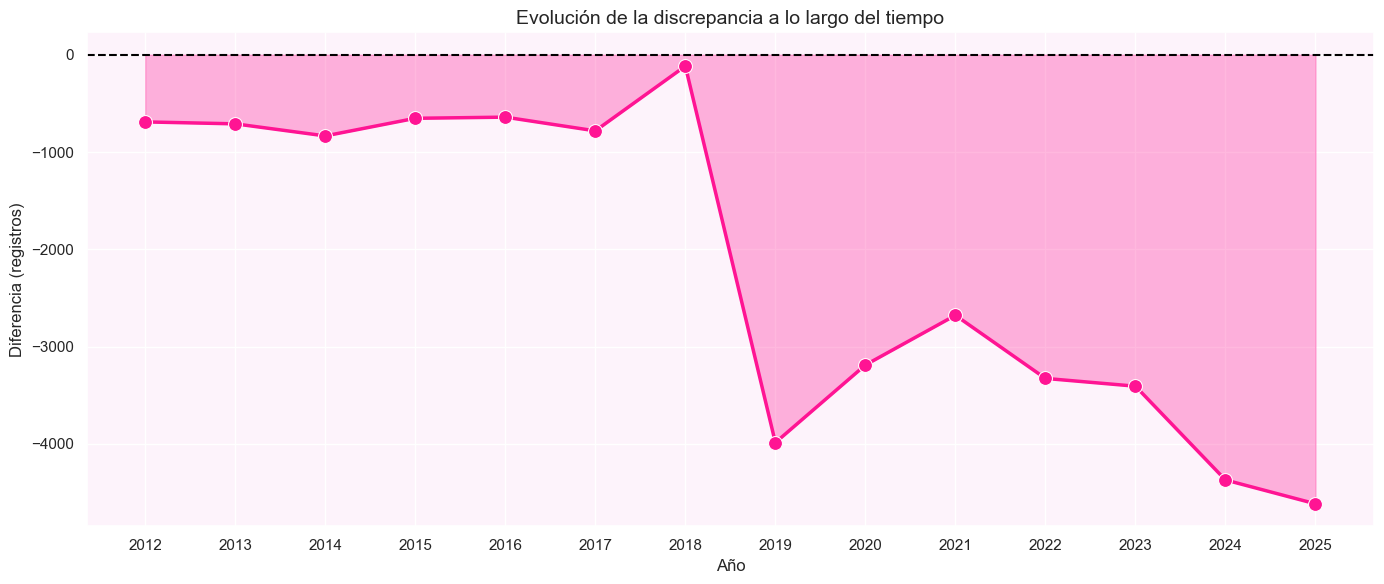

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=df_comp, x='year', y='diferencia', marker='o', 
             linewidth=2.5, markersize=10, ax=ax, color='deeppink')
ax.fill_between(df_comp['year'], df_comp['diferencia'], alpha=0.3, color='deeppink')
ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Diferencia (registros)', fontsize=12)
ax.set_title('Evolución de la discrepancia a lo largo del tiempo', fontsize=14)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.xticks(df_comp['year'])
plt.tight_layout()
plt.savefig('evolucion_discrepancia.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
for year in range(2012, 2026):
    print(f"\n--- AÑO {year} ---")
    total_anual = df_comp[df_comp['year'] == year]['total_anual'].values[0]
    suma_meses = df_comp[df_comp['year'] == year]['suma_meses'].values[0]
    diferencia = df_comp[df_comp['year'] == year]['diferencia'].values[0]
    
    print(f"Total Anual:  {total_anual:,}")
    print(f"Suma Meses:   {suma_meses:,}")
    print(f"Diferencia:   {diferencia:,} ({df_comp[df_comp['year'] == year]['porcentaje_diff'].values[0]:.2f}%)")
    
    #  desglose mensual
    meses_year = df_mensual[df_mensual['year'] == year].copy()
    meses_year = meses_year.sort_values('fecha_inicio')
    print("\nDesglose mensual:")
    for _, row in meses_year.iterrows():
        mes_nombre = row['fecha_inicio'].strftime('%B')
        print(f"  {mes_nombre:12s}: {row['total']:,}")



ANÁLISIS DETALLADO POR AÑO

--- AÑO 2012 ---
Total Anual:  4,882
Suma Meses:   5,572
Diferencia:   -690 (-14.13%)

Desglose mensual:
  January     : 463
  February    : 420
  March       : 471
  April       : 457
  May         : 486
  June        : 523
  July        : 482
  August      : 435
  September   : 463
  October     : 463
  November    : 382
  December    : 527

--- AÑO 2013 ---
Total Anual:  5,315
Suma Meses:   6,025
Diferencia:   -710 (-13.36%)

Desglose mensual:
  January     : 436
  February    : 358
  March       : 466
  April       : 545
  May         : 525
  June        : 532
  July        : 463
  August      : 577
  September   : 554
  October     : 579
  November    : 468
  December    : 522

--- AÑO 2014 ---
Total Anual:  6,179
Suma Meses:   7,013
Diferencia:   -834 (-13.50%)

Desglose mensual:
  January     : 573
  February    : 685
  March       : 637
  April       : 514
  May         : 647
  June        : 671
  July        : 544
  August      : 675
  September   :

In [42]:
print(f"Diferencia promedio:      {df_comp['diferencia'].mean():,.0f} registros")
print(f"Diferencia mediana:       {df_comp['diferencia'].median():,.0f} registros")
print(f"Diferencia máxima:        {df_comp['diferencia'].max():,.0f} registros (año {df_comp.loc[df_comp['diferencia'].idxmax(), 'year']:.0f})")
print(f"Diferencia mínima:        {df_comp['diferencia'].min():,.0f} registros (año {df_comp.loc[df_comp['diferencia'].idxmin(), 'year']:.0f})")
print(f"% promedio de diferencia: {df_comp['porcentaje_diff'].mean():.2f}%")

Diferencia promedio:      -2,143 registros
Diferencia mediana:       -1,756 registros
Diferencia máxima:        -116 registros (año 2018)
Diferencia mínima:        -4,616 registros (año 2025)
% promedio de diferencia: -15.95%
